# Cancer Mutation Classification
This pipeline classifies genetic mutations as **Oncogenic** or **Non-Oncogenic** using a multi-tiered labeling strategy based on ClinVar's Oncogenicity annotations, Somatic Clinical Impact tiers, and cancer-phenotype-matched pathogenicity data.

In [2]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_clean_data
from src.features import FeatureEngineer
from src.training import train_pipeline
from src.evaluation import evaluate_medical_utility, plot_visual_assessment
from src.config import RANDOM_STATE, TEST_SIZE

from src.gpu_setup import setup_gpu
setup_gpu()
import pickle
from tensorflow.keras.models import load_model

I0000 00:00:1782070733.589351  203670 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782070733.682399  203670 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782070735.556344  203670 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU Mode Active: 1 Physical GPUs, 1 Logical GPUs configured.


I0000 00:00:1782070736.265573  203670 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2215 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 1. Data Procurement
Loading variants with multi-tiered cancer-specific labeling:
- **Tier 1 (Gold):** ClinVar Oncogenicity = "Oncogenic" or "Likely oncogenic"
- **Tier 2 (Silver):** Somatic Clinical Impact = Tier I or Tier II
- **Tier 3 (Bronze):** Pathogenic + Cancer phenotype keywords
- **Negative:** ClinSigSimple = 0 (reliably benign)

In [4]:
df = load_clean_data()

train_df, test_df = train_test_split(
    df, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=df['CancerLabel']
)

print(f"Training set: {len(train_df)} variants")
print(f"Test set: {len(test_df)} variants")

Dataset successfully loaded. Final size: 600185 variants.
  Oncogenic (positive): 23296 (3.9%)
  Benign (negative):    576889 (96.1%)
Training set: 510157 variants
Test set: 90028 variants


/tmp/ipykernel_203670/587477289.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CancerLabel', data=df, palette=['#3498db', '#e74c3c'])


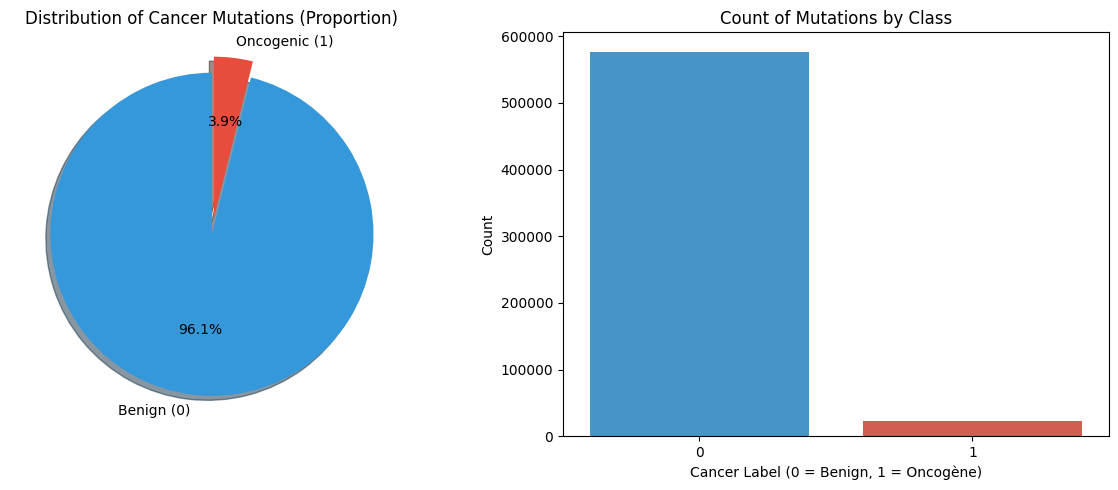

Valeurs exactes:
CancerLabel
0    576889
1     23296
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization of Class Imbalance
plt.figure(figsize=(12, 5))

# 1. Pie Chart
plt.subplot(1, 2, 1)
class_counts = df['CancerLabel'].value_counts()
labels = ['Benign (0)', 'Oncogenic (1)']
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=['#3498db', '#e74c3c'], explode=(0, 0.1), shadow=True)
plt.title('Distribution of Cancer Mutations (Proportion)')

# 2. Bar Chart
plt.subplot(1, 2, 2)
sns.countplot(x='CancerLabel', data=df, palette=['#3498db', '#e74c3c'])
plt.title('Count of Mutations by Class')
plt.xlabel('Cancer Label (0 = Benign, 1 = Oncogène)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("Valeurs exactes:")
print(class_counts)

## 2. Feature Engineering & Preparation
Extracting biological features: Ti/Tv ratio, origin (somatic/germline), allele length, gene-level oncogenic frequency, and categorical embeddings for Gene, Chromosome, Variant Type, and Origin.

In [6]:
engineer = FeatureEngineer()
X_train = engineer.fit_transform(train_df)
X_test = engineer.transform(test_df)

y_train = train_df['CancerLabel'].values
y_test = test_df['CancerLabel'].values

## 3. Neural Architecture & Training
The model uses Focal Loss (alpha=0.75) combined with computed class weights to handle severe class imbalance. Architecture: 256→128→64 dense layers with embedding inputs for categorical features.

In [7]:
model, history = train_pipeline(X_train, y_train, engineer)

# Save the model and feature engineer for future usey
if not os.path.exists('models'):
    os.makedirs('models')
model.save('models/mutation_classifier.h5')
with open('models/feature_engineer.pkl', 'wb') as f:
    pickle.dump(engineer, f)
print("Model and Feature Engineer saved successfully in 'models/' directory.")

Class weights: {np.int64(0): np.float64(0.5201914939176719), np.int64(1): np.float64(12.881451368548632)}
Epoch 1/100


I0000 00:00:1782070821.663459  206469 service.cc:153] XLA service 0x7f92a8039050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782070821.663538  206469 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1782070821.748117  206469 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782070822.130145  206469 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1782070822.207185  206469 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3966__.38
I0000 00:00:1782070824.799168  207634 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1782070826.566418  207637 subprocess_compilation.cc:348] pt

 15/847 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7471 - loss: 0.0591 - precision: 0.0849 - recall: 0.4813    

I0000 00:00:1782070829.425286  206469 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_maximum_reduce_fusion', 4 bytes spill stores, 8 bytes spill loads

I0000 00:00:1782070829.449687  206469 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


820/847 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9435 - loss: 0.0184 - precision: 0.3856 - recall: 0.5564

I0000 00:00:1782070832.073767  206467 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3966__.38


847/847 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9440 - loss: 0.0182 - precision: 0.3888 - recall: 0.5589

I0000 00:00:1782070839.056830  206462 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


847/847 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9602 - loss: 0.0129 - precision: 0.4901 - recall: 0.6337 - val_accuracy: 0.9758 - val_loss: 0.0088 - val_precision: 0.6973 - val_recall: 0.6705 - learning_rate: 0.0010
Epoch 2/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9711 - loss: 0.0091 - precision: 0.6136 - recall: 0.6877 - val_accuracy: 0.9737 - val_loss: 0.0087 - val_precision: 0.6507 - val_recall: 0.7079 - learning_rate: 0.0010
Epoch 3/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9727 - loss: 0.0087 - precision: 0.6342 - recall: 0.6983 - val_accuracy: 0.9765 - val_loss: 0.0088 - val_precision: 0.7071 - val_recall: 0.6792 - learning_rate: 0.0010
Epoch 4/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9734 - loss: 0.0084 - precision: 0.6434 - recall: 0.7062 - val_accuracy: 0.9735 - val_loss: 0.0089 - val_precision: 0.6422 - val_recall: 0.7260 - learning_rate: 0.0010
Epoch 5/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.973

Model and Feature Engineer saved successfully in 'models/' directory.


## 4. Medical Utility Assessment

2814/2814 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

--- Clinical Performance Appraisal (Threshold: 0.3550) ---
                   precision    recall  f1-score   support

Non-Oncogenic (0)       1.00      0.92      0.95     86534
    Oncogenic (1)       0.30      0.90      0.45      3494

         accuracy                           0.92     90028
        macro avg       0.65      0.91      0.70     90028
     weighted avg       0.97      0.92      0.93     90028



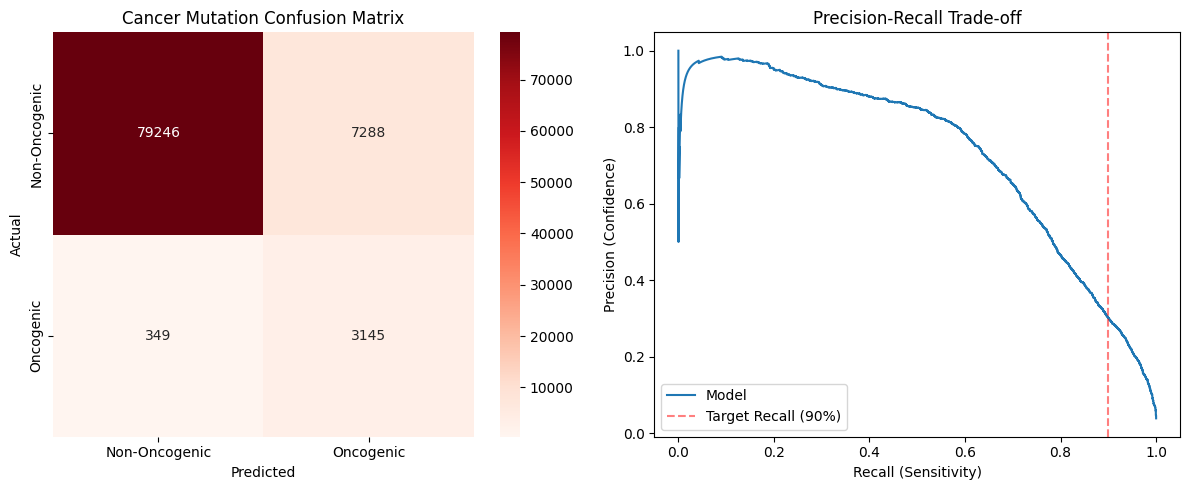

In [8]:
y_pred, y_probs, threshold = evaluate_medical_utility(model, X_test, y_test)
plot_visual_assessment(y_test, y_pred, y_probs)

=== Évaluation Détaillée ===
F1-Score  : 0.4516
AUC-ROC   : 0.9714
Précision : 0.3014



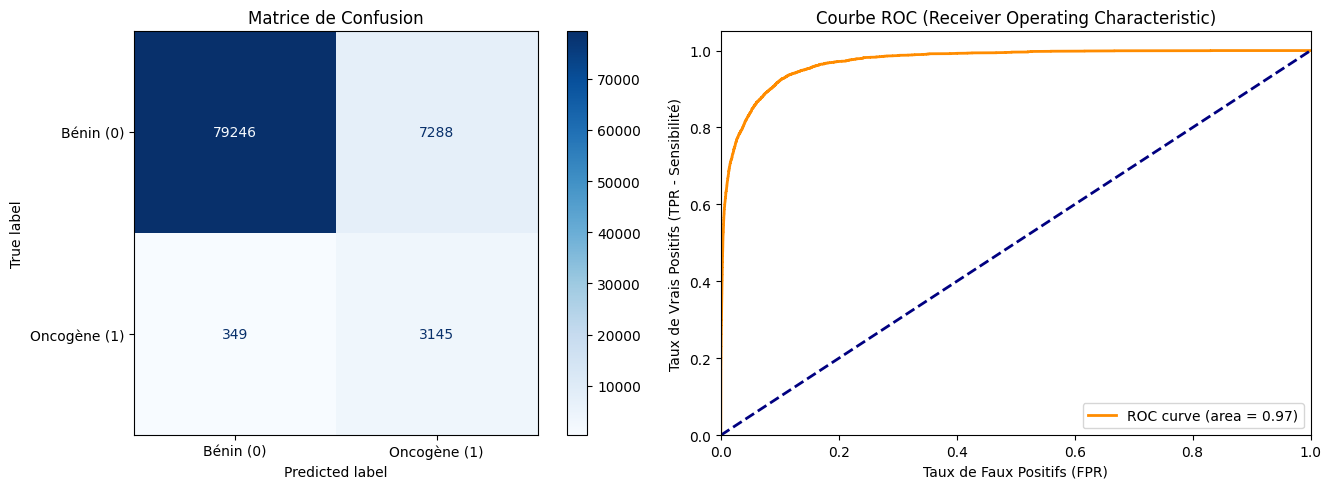

In [27]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

# Calcul des métriques
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)
precision = precision_score(y_test, y_pred)

print("=== Évaluation Détaillée ===")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC-ROC   : {roc_auc:.4f}")
print(f"Précision : {precision:.4f}\n")

# Affichage des graphiques (Matrice de Confusion et Courbe ROC)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bénin (0)', 'Oncogène (1)'])
disp.plot(cmap='Blues', values_format='d', ax=ax[0])
ax[0].set_title('Matrice de Confusion')

# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Taux de Faux Positifs (FPR)')
ax[1].set_ylabel('Taux de Vrais Positifs (TPR - Sensibilité)')
ax[1].set_title('Courbe ROC (Receiver Operating Characteristic)')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 5. Interactive Clinical Inference & Interpretation
To test the model with an easy-to-use graphical interface, we have built a Flask web application.

**Instructions:**
1. Open a terminal in the project root.
2. Run `python webapp/app.py`.
3. Click the link (e.g. `http://127.0.0.1:5000`) to open the web app in your browser.